In [ ]:
# import pandas as pd

# # Load the dataset
# df = pd.read_csv('scheduling_2k.csv')

# # List of columns identified as 'Noise' or metadata not needed for scheduling logic
# columns_to_drop = [
#     'Unnamed: 0', 'vertical_scaling', 'scheduler', 'cycles_per_instruction', 
#     'memory_accesses_per_instruction', 'cpu_usage_distribution', 
#     'tail_cpu_usage_distribution', 'page_cache_memory', 'sample_rate', 
#     'alloc_collection_id', 'instance_index', 'user', 'collection_name', 
#     'collection_logical_name', 'start_after_collection_ids', 'average_usage', 
#     'maximum_usage', 'random_sample_usage', 'assigned_memory', 
#     'cluster', 'event', 'failed'
# ]

# # Dropping the columns
# df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')

# # Save the cleaned dataset for further use
# df_cleaned.to_csv('scheduling_2k.csv', index=False)

# print("Columns dropped successfully. Data saved to 'scheduling_data_cleaned.csv'.")

Columns dropped successfully. Data saved to 'scheduling_data_cleaned.csv'.


In [ ]:
# import pandas as pd
# import ast
# import numpy as np

# # Load the cleaned dataset
# df = pd.read_csv('scheduling_data_cleaned.csv')

# # 1. Parse 'resource_request'
# # The data is stored as a string dictionary. We extract numeric values for CPUS and Memory.
# def parse_resource(row):
#     try:
#         # safely evaluate the string dictionary
#         res_dict = ast.literal_eval(row)
#         return pd.Series([res_dict.get('cpus', 0), res_dict.get('memory', 0)])
#     except:
#         return pd.Series([0, 0])

# print("Extracting resource requirements...")
# df[['cpu_request', 'memory_request']] = df['resource_request'].apply(parse_resource)

# # 2. Calculate Job Duration
# # This is the processing time required on a server.
# # Math: Duration = |End Time - Start Time|
# df['duration'] = (df['end_time'] - df['start_time']).abs()

# # 3. Generate Synthetic Deadlines
# # Since real-world traces often lack explicit deadlines, we calculate them 
# # based on a 'slack factor' tied to job priority.
# # High priority = tight deadline; Low priority = loose deadline.
# print("Calculating deadlines based on priority slack...")
# max_pri = df['priority'].max() if df['priority'].max() > 0 else 1

# def calculate_deadline(row):
#     # If priority is in the top 30%, give it 20% extra time (tight)
#     # Otherwise, give it 150% extra time (loose)
#     slack = 1.2 if row['priority'] > (max_pri * 0.7) else 2.5
#     return row['time'] + (row['duration'] * slack)

# df['deadline'] = df.apply(calculate_deadline, axis=1)

# # 4. Discretize Time into Slots
# # We group the continuous microsecond timestamps into 5-minute 'bins'.
# # 5 minutes = 300,000,000 microseconds
# MICROSECONDS_PER_5_MIN = 300000000
# df['time_slot'] = df['time'] // MICROSECONDS_PER_5_MIN

# # 5. Define Server Capacities
# # We assign a normalized total capacity to each server (machine_id).
# df['server_cpu_cap'] = 1.0
# df['server_mem_cap'] = 1.0

# # 6. Final Clean-up
# # We drop the original string column and save the enriched version.
# df_final = df.drop(columns=['resource_request'])
# df_final.to_csv('scheduling_data_final.csv', index=False)

# print("\nSuccess! Final columns for Scheduling Graph:")
# print(df_final[['collection_id', 'cpu_request', 'duration', 'deadline', 'time_slot']].head())

Extracting resource requirements...
Calculating deadlines based on priority slack...

Success! Final columns for Scheduling Graph:
   collection_id  cpu_request   duration      deadline  time_slot
0    94591244395     0.020660  300000000  7.500000e+08          0
1   260697606809     0.007240    1000000  2.517307e+12       8391
2   276227177776     0.048584  300000000  1.964340e+11        652
3    10507389885     0.070435  300000000  7.500000e+08          0
4    25911621841     0.002449    2000000  1.810632e+12       6035


In [ ]:
# import pandas as pd

# df = pd.read_csv('scheduling_data_final.csv', nrows=50000)
# df = df.head(2000)
# df.to_csv('scheduling_final_2k.csv', index=False)
# df.to_excel('scheduling_final_2k.xlsx', index=False)

### Old Version [traingular constraint]

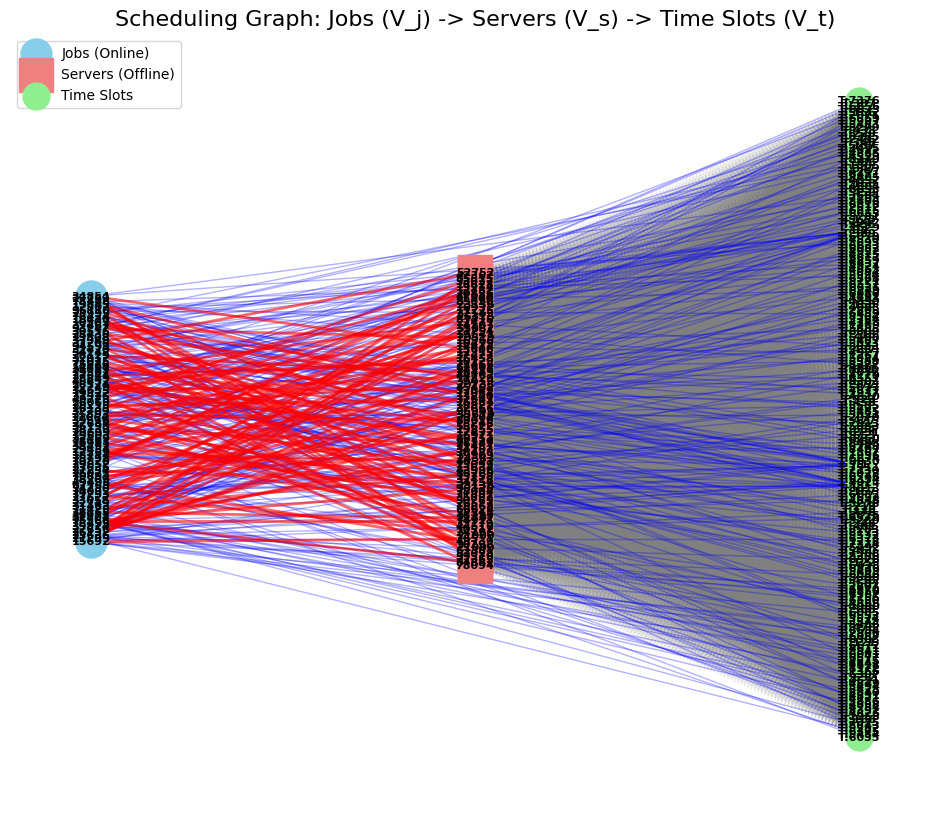

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 1. Load the Enriched Dataset
df = pd.read_csv('scheduling_final_2k.csv')

# We'll visualize a subset (top 5 jobs) to ensure the graph is readable 
# and doesn't become a "black ink" mess.
df_sub = df.head(100).copy()

# 2. Initialize the Graph
G = nx.Graph()

# Setup partition mapping: 0=Jobs, 1=Servers, 2=Time Slots
involved_servers = set()
involved_slots = set()

for _, row in df_sub.iterrows():
    job_id = f"Job_{row['collection_id']}"
    server_id = f"Server_{row['machine_id']}"
    
    # Add Job Node (Left Partition)
    G.add_node(job_id, partition=0, type='job', label=str(row['collection_id'])[:5])
    
    # Add Server Node (Center Partition - Offline Hub)
    G.add_node(server_id, partition=1, type='server', label=str(row['machine_id'])[:5])
    involved_servers.add(server_id)
    
    # Add Time Slot Nodes (Right Partition)
    # We display the range from arrival to deadline for each job
    start_slot = int(row['time_slot'])
    end_slot = int(row['deadline']) // 300000000 # 5-min slot conversion
    
    for t in range(start_slot, end_slot + 1):
        time_node = f"Time_{t}"
        G.add_node(time_node, partition=2, type='time', label=f"T:{t}")
        involved_slots.add(time_node)
        
        # RULE: Job -> Time (The temporal window for scheduling)
        G.add_edge(job_id, time_node, edge_type='window')

    # RULE: Job -> Server (Structural compatibility)
    G.add_edge(job_id, server_id, edge_type='compat')

# RULE: Server -> Time (Availability of the resource over time)
for s in involved_servers:
    for t_node in involved_slots:
        G.add_edge(s, t_node, edge_type='avail')

# 3. Create the Visualization
# Use multipartite_layout to force the 3-column structure
pos = nx.multipartite_layout(G, subset_key="partition")

# Separate nodes for custom styling
jobs = [n for n, d in G.nodes(data=True) if d['partition'] == 0]
servers = [n for n, d in G.nodes(data=True) if d['partition'] == 1]
times = [n for n, d in G.nodes(data=True) if d['partition'] == 2]

plt.figure(figsize=(12, 10))
plt.title("Scheduling Graph: Jobs (V_j) -> Servers (V_s) -> Time Slots (V_t)", fontsize=16)

# --- Draw Edges ---
# Server-Time availability (Dotted light lines)
avail_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'avail']
nx.draw_networkx_edges(G, pos, edgelist=avail_edges, edge_color='gray', alpha=0.1, style='dotted')

# Job-Time window (Blue lines)
window_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'window']
nx.draw_networkx_edges(G, pos, edgelist=window_edges, edge_color='blue', alpha=0.3)

# Job-Server compatibility (Solid red lines)
compat_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'compat']
nx.draw_networkx_edges(G, pos, edgelist=compat_edges, edge_color='red', alpha=0.6, width=2)

# --- Draw Nodes ---
nx.draw_networkx_nodes(G, pos, nodelist=jobs, node_color='skyblue', node_size=500, label='Jobs (Online)')
nx.draw_networkx_nodes(G, pos, nodelist=servers, node_color='lightcoral', node_shape='s', node_size=625, label='Servers (Offline)')
nx.draw_networkx_nodes(G, pos, nodelist=times, node_color='lightgreen', node_size=375, label='Time Slots')

# Add Labels
labels = nx.get_node_attributes(G, 'label')
nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight='bold')

plt.legend(scatterpoints=1, loc='upper left')
plt.axis('off')
plt.show()

### Updated : [removed traingular constraints]

Path = (Job1 --​Red--->​ ServerX --​Green---> ​Time5​)

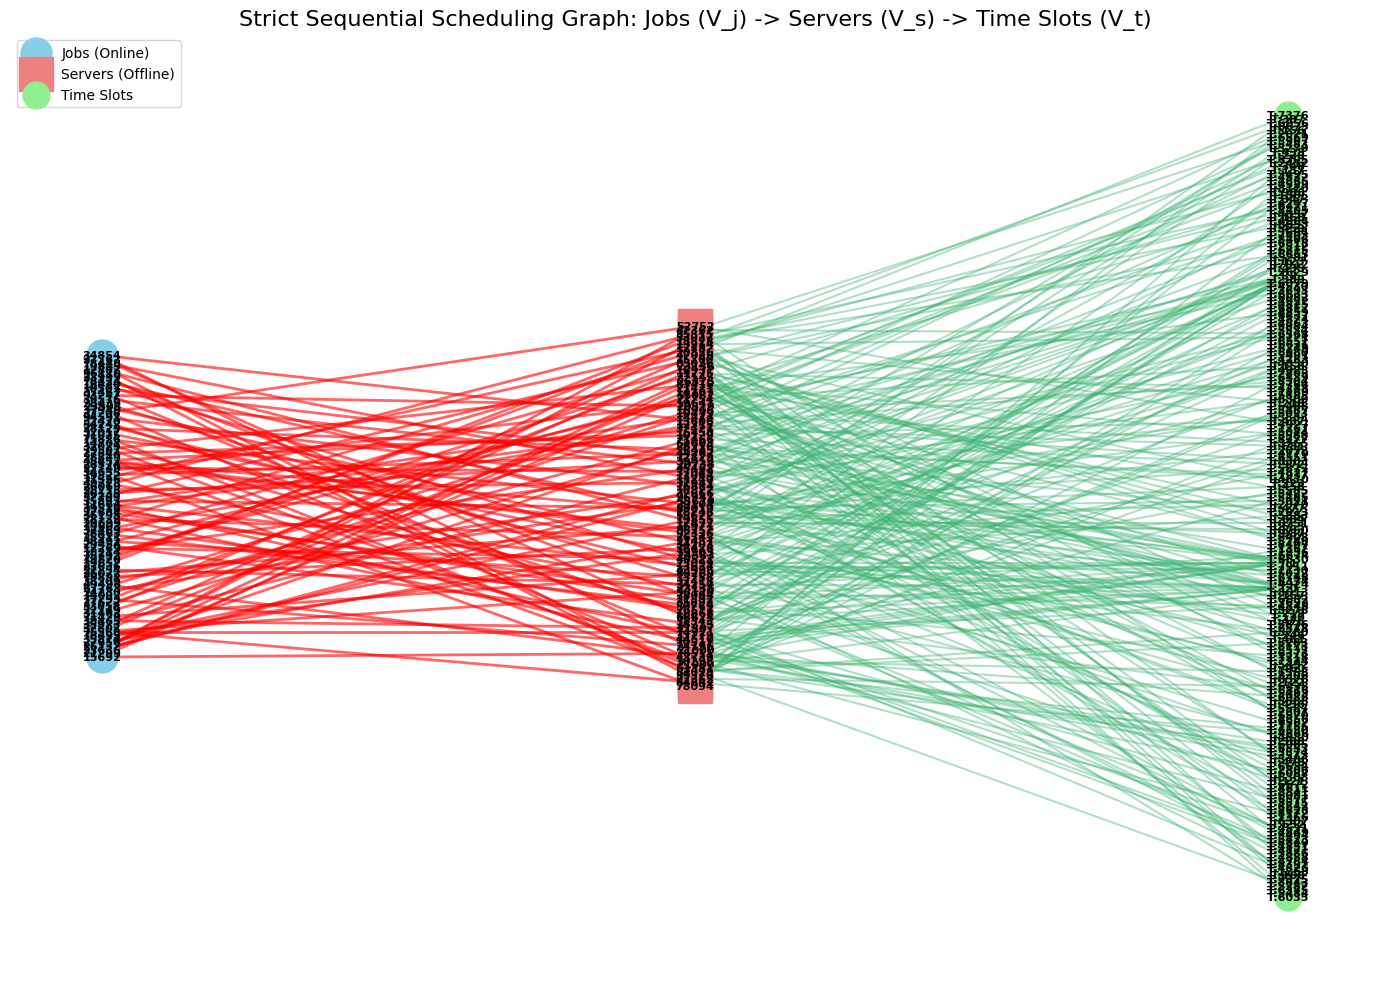

In [6]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
df = pd.read_csv('scheduling_final_2k.csv')
df_sub = df.head(100).copy()
G = nx.Graph()

# Setup partition mapping: 0=Jobs, 1=Servers, 2=Time Slots
involved_servers = set()
involved_slots = set()

for _, row in df_sub.iterrows():
    job_id = f"Job_{row['collection_id']}"
    server_id = f"Server_{row['machine_id']}"
    
    # Add Job Node (Left Partition)
    G.add_node(job_id, partition=0, type='job', label=str(row['collection_id'])[:5])
    
    # Add Server Node (Center Partition)
    G.add_node(server_id, partition=1, type='server', label=str(row['machine_id'])[:5])
    involved_servers.add(server_id)
    
    # RULE 1: Job -> Server (Structural compatibility)
    # Flows from Left to Center
    G.add_edge(job_id, server_id, edge_type='compat')
    
    # Add Time Slot Nodes (Right Partition)
    start_slot = int(row['time_slot'])
    end_slot = int(row['deadline']) // 300000000 # 5-min slot conversion
    
    for t in range(start_slot, end_slot + 1):
        time_node = f"Time_{t}"
        G.add_node(time_node, partition=2, type='time', label=f"T:{t}")
        involved_slots.add(time_node)
        
        # RULE 2: Server -> Time (Valid Temporal Window)
        # Flows from Center to Right (NO MORE BYPASSING)
        # The server is available at this time slot specifically to serve this job's window
        G.add_edge(server_id, time_node, edge_type='valid_window')

# 3. Create the Visualization
# Use multipartite_layout to force the 3-column structure
pos = nx.multipartite_layout(G, subset_key="partition")

# Separate nodes for custom styling
jobs = [n for n, d in G.nodes(data=True) if d.get('partition') == 0]
servers = [n for n, d in G.nodes(data=True) if d.get('partition') == 1]
times = [n for n, d in G.nodes(data=True) if d.get('partition') == 2]

plt.figure(figsize=(14, 10))
plt.title("Strict Sequential Scheduling Graph: Jobs (V_j) -> Servers (V_s) -> Time Slots (V_t)", fontsize=16)

# --- Draw Edges ---
compat_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'compat']
window_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'valid_window']

# Left to Center: Job-Server compatibility (Solid red lines)
nx.draw_networkx_edges(G, pos, edgelist=compat_edges, edge_color='red', alpha=0.6, width=2)

# Center to Right: Server-Time window (Solid green lines)
nx.draw_networkx_edges(G, pos, edgelist=window_edges, edge_color='mediumseagreen', alpha=0.4, width=1.5)

nx.draw_networkx_nodes(G, pos, nodelist=jobs, node_color='skyblue', node_size=500, label='Jobs (Online)')
nx.draw_networkx_nodes(G, pos, nodelist=servers, node_color='lightcoral', node_shape='s', node_size=625, label='Servers (Offline)')
nx.draw_networkx_nodes(G, pos, nodelist=times, node_color='lightgreen', node_size=375, label='Time Slots')

labels = nx.get_node_attributes(G, 'label')
nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight='bold')

plt.legend(scatterpoints=1, loc='upper left')
plt.axis('off')
plt.tight_layout()
plt.show()